In [1]:
# pip install torch torchaudio torchcodec 
# pip install transformers jiwer
import os 
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm.notebook import tqdm # for displaying process bar
import torch 
import torch.nn as nn 
from torch import optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T 
import torchaudio.functional as F 
from transformers import Wav2Vec2CTCTokenizer, get_cosine_schedule_with_warmup 
from jiwer import wer # to evaluate the model 

c:\Users\HuyenDT\source\repos\sttproject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### DeepSpeech2: Intro to ASR 
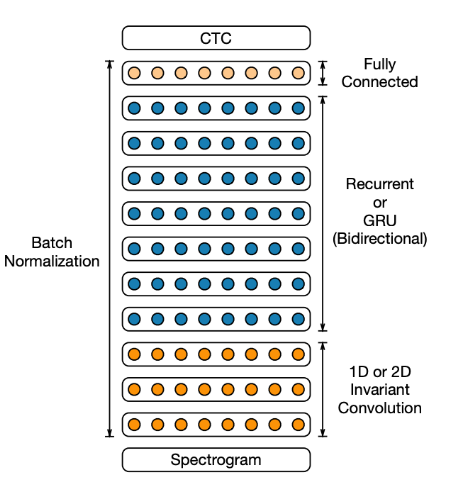

In [2]:
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("facebook/wav2vec2-base")
tokenizer # tokenizer nào cũng na ná nhau thôi, dùng cái này có sẵn đã có decoder trong đó rồi 

Wav2Vec2CTCTokenizer(name_or_path='facebook/wav2vec2-base', vocab_size=32, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'word_delimiter_token': '|'}, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	1: AddedToken("<s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	2: AddedToken("</s>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	3: AddedToken("<unk>", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	4: AddedToken("|", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [3]:
tokenizer.vocab
# <pad>: blank token for repeating characters vd: hh.ee.ll.-.lo => colapse into hello

{'<pad>': 0,
 '<s>': 1,
 '</s>': 2,
 '<unk>': 3,
 '|': 4,
 'E': 5,
 'T': 6,
 'A': 7,
 'O': 8,
 'N': 9,
 'I': 10,
 'H': 11,
 'S': 12,
 'R': 13,
 'D': 14,
 'L': 15,
 'U': 16,
 'M': 17,
 'W': 18,
 'C': 19,
 'F': 20,
 'G': 21,
 'Y': 22,
 'P': 23,
 'B': 24,
 'V': 25,
 'K': 26,
 "'": 27,
 'X': 28,
 'J': 29,
 'Q': 30,
 'Z': 31}

In [4]:
os.listdir("C:/Users/HuyenDT/Downloads/LibriSpeech")

['BOOKS.TXT',
 'CHAPTERS.TXT',
 'dev-other',
 'LICENSE.TXT',
 'README.TXT',
 'SPEAKERS.TXT']

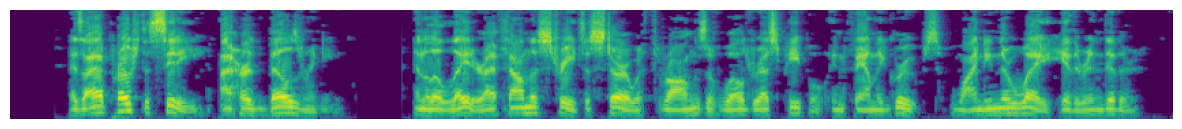

In [11]:
class LibrispeechDataset(Dataset):
    def __init__(self, 
                 path_to_data_root, 
                 include_splits = ["dev-other"], # ["train-clean-100", "train-clean-360", "train-other-500"], 
                 sampling_rate = 16000, 
                 num_audio_channels = 1): 
        
        self.sampling_rate = sampling_rate 
        self.num_audio_channels = num_audio_channels

        if isinstance(include_splits, str): # if it is a string 
            include_splits = [include_splits] # to make sure include_splits is a list, even if it is a string => 1 item
        
        self.librispeech_data = []
        for s in include_splits: 
            path_to_split = os.path.join(path_to_data_root, s)  # format: speaker/section/audio
            
            for speaker in os.listdir(path_to_split): 
                path_to_speaker = os.path.join(path_to_split, speaker)
                # print(speaker)

                for section in os.listdir(path_to_speaker): 
                    path_to_section = os.path.join(path_to_speaker, section)
                    files = os.listdir(path_to_section)

                    transcript_file = [path for path in files if ".txt" in path][0]
                    with open(os.path.join(path_to_section, transcript_file), "r") as f: 
                        transcripts = f.readlines()

                    for line in transcripts: 
                        split_line = line.split() # default is space => return an array
                        audio_root = split_line[0]
                        audio_file = audio_root + ".flac"
                        full_path_to_audio_file = os.path.join(path_to_section, audio_file)
                        transcript = " ".join(split_line[1:]).strip()

                        self.librispeech_data.append(
                            (full_path_to_audio_file, transcript)
                        )
        # print(len(self.librispeech_data))
        # Create a transform to transfrom the audio waveform → Mel Spectrogram: display Frequency by time (Time × Frequency)
        # Waveform (1D signal) => STFT (Fourier Transform) -> Mel scaling -> Mel Spectrogram (2D tensor)
        # Mel scale: based on how people can hear the voice to separate into level (is log(Hz))
        # n_fft?, window_size? window_fn: torch.hann_window
        self.audio2mels = T.MelSpectrogram( # default n_fft & hanning_window
            sample_rate = sampling_rate, # tấn suất lấy mẫu của audio: esim: 16000 Hz = 1 giây có 16000 mẫu
            n_mels=80 # Mel filter banks: (optimal value) Output sẽ có 80 hàng (80 tần số mel), => chia trục tần số thành 80 dải Mel.
                      # 40: lost data, 128-256: heavy, more RAM, and training time,
        )

        self.amp2db = T.AmplitudeToDB(
            top_db=80.0
        )


    def __len__(self): 
        '''
        __len__: 
            - DataLoader biết dataset có bao nhiêu mẫu
            - Tính số batch
            - Shuffle đúng cách
        '''
        return len(self.librispeech_data)
    
    def __getitem__(self, index):
        path_to_audio, transcript = self.librispeech_data[index]
        audio, orig_sr = torchaudio.load(path_to_audio, normalize=True) #normalize: true, convert into [-1, 1], normalize: false, audio bit is between [0, 255]
        if orig_sr != self.sampling_rate:
            audio = torchaudio.functional.resample(audio, orig_freq=orig_sr, new_freq=self.sampling_rate) # re-sample to 16.000

        # audio: waveform
        mel = self.audio2mels(audio) # to MelSpectrogram
        # print(audio.shape) => [1, 170400]
        # print(mel.shape)  
        # => [1, 80, 853]: 80 bins, 
        # 853 time steps: after sliding window of hann_window (400 windowsize with 200 overlap default value)

        mel = self.amp2db(mel) # to amplitude to Decibel => see diff frequencies lighting up at the diff time steps
        
        # plt.figure(figsize=(15,5))
        # plt.imshow(mel[0])
        # plt.show()

        mel = (mel - mel.mean())/(mel.std() + 1e-6) # 1e-6 to avoid deviding by zero, to nomalize

        tokenized_transcript = torch.tensor(tokenizer.encode(transcript))
        # print(transcript)
        # print(tokenized_transcript)

        sample = {
            "input_values": mel[0].T, # to feed time dimension first, then feature dimension after
            "labels": tokenized_transcript,
            "audio": audio,
            "transcript": transcript
        }
        return sample


# Load a sample and visualize
dataset = LibrispeechDataset("C:/Users/HuyenDT/Downloads/LibriSpeech", include_splits = ["dev-other"])

sample =next(iter(dataset))

# visualize (and flip so low frequencies are at the bottom)
plt.figure(figsize=(15, 5))
plt.imshow(sample["input_values"].T)
plt.axis("off")
plt.gca().invert_yaxis() # gca: Get Current Axes
plt.show()

In [ ]:
from IPython.display import Audio 

audio = sample["audio"]
sample_rate = 1600

print(sample["transcript"])
Audio(audio, rate=sample_rate)

AS I APPROACHED THE CITY I HEARD BELLS RINGING AND A LITTLE LATER I FOUND THE STREETS ASTIR WITH THRONGS OF WELL DRESSED PEOPLE IN FAMILY GROUPS WENDING THEIR WAY HITHER AND THITHER


In [ ]:
import matplotlib.pyplot as plt 
import numpy as np 

def drawWaveform (audioLen, axes): 
    start_time_ms = 0 
    end_time_ms = audioLen # milliseconds: 10, 100, 1000: this is how amplitude values look like for the first 10, 100... miliseconds

    start_idx = int(start_time_ms * sample_rate / 1000) # sample_rate/sec => need to divide by 1000
    end_idx = int(end_time_ms * sample_rate / 1000)

    audio_np = audio[start_idx: end_idx]

    # Create time axis in milliseconds
    time_ms = np.arange(len(audio_np)) * (1000/sample_rate)

    axes.plot(time_ms, audio_np)
    axes.set_xlabel('Time (ms)')
    axes.set_ylabel('Amplitude')
    axes.set_title(f"Audio waveform ({audioLen} milliseconds)")
    # plt.show()

fig, axes = plt.subplots(2, 2, figsize=(20, 6))
axes = axes.flatten() 

drawWaveform(10, axes[0])
drawWaveform(100, axes[1])
drawWaveform(1000, axes[2])
plt.tight_layout()

### Collate Function 
- spectrograms: Pad spectrograms to longest in the batch and concatenate 
- seq_lens: just so we know the original size of each sample before we padded 
- packed_transcript: Packed Padding of Labels (CTC Loss can take a single vector of all target tokens across all samples in the batch)
- target_lengths: Because we concatenated all our labels into a single vector, CTC needs to know how mnay token go with each sample in the batch 

=> RNN in PyTorch can take Packed Padded data => only need to sort the seq lengths in the batch are longest to shortest 

Input Values: torch.Size([5, 1, 80, 853])
Seq Lens: tensor([853, 771, 691, 298, 293])
Labels: torch.Size([550])
Target Lengths: tensor([181, 141, 114,  61,  53])
OK, same length


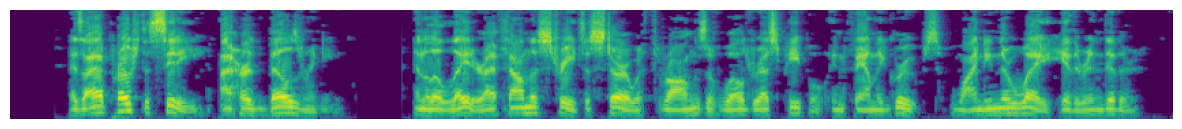

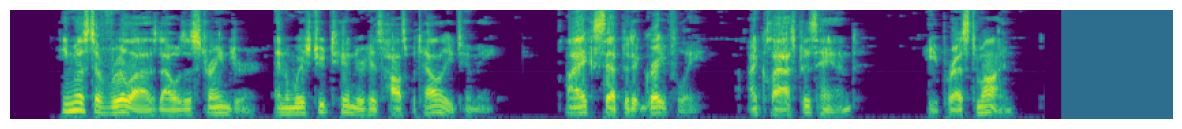

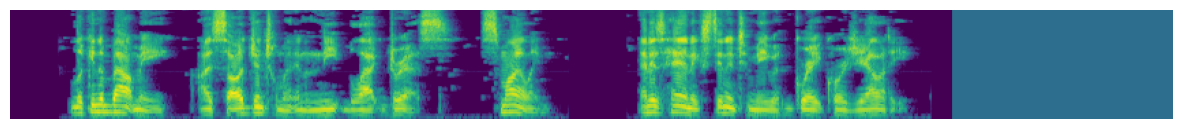

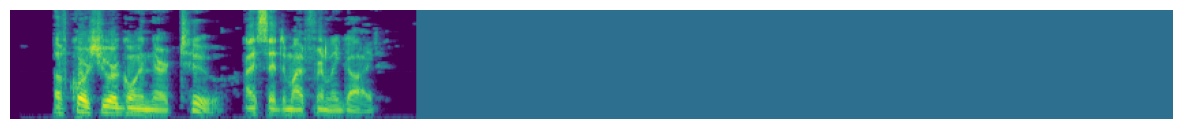

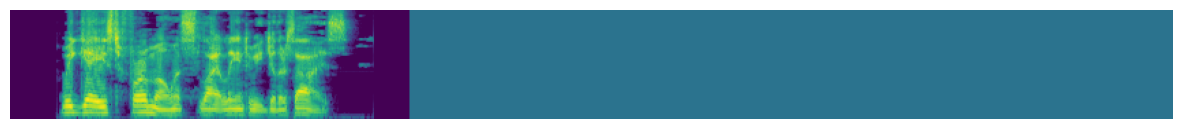

In [ ]:
def collate_fun(batch): # combine multiple samples into batchs
    #print(batch[0]["input_values"].shape)  # time steps of each audio is 853
    #print(batch[1]["input_values"].shape)  # each has diff length 

    batch = sorted(batch, key = lambda x: x["input_values"].shape[0], reverse=True)
    # print(batch[0]["input_values"].shape)  # after sort 
    # print(batch[1]["input_values"].shape) 
    

    batch_mels = [sample["input_values"] for sample in batch]
    batch_transcripts = [sample["labels"] for sample in batch]

    seq_lens = torch.tensor([b.shape[0] for b in batch_mels], dtype=torch.long)

    spectrograms = torch.nn.utils.rnn.pad_sequence(batch_mels, batch_first=True, padding_value=0)
    # print(spectrograms.shape) # [5, 853, 80]: batch_size, seq length, hidden size 
    
    spectrograms = spectrograms.unsqueeze(1) # add 1 more dimension after the first dimension, unsqueeze(0): at the beginning, unsqueeze(-1): at the end 
    # print(spectrograms.shape) # [5, 1, 853, 80]

    spectrograms = spectrograms.transpose(-1, -2) # switch the position of 2 last dimensions

    target_lengths = torch.tensor([len(t) for t in batch_transcripts], dtype=torch.long)
    packed_transcripts = torch.cat(batch_transcripts)

    # print(target_lengths)
    # print(packed_transcripts)
    batch = {
        "input_values": spectrograms,
        "seq_lens": seq_lens, 
        "labels": packed_transcripts, 
        "target_lengths": target_lengths
    }

    return batch

# test collate func 
loader = DataLoader(dataset=dataset, batch_size=5, collate_fn=collate_fun)
batch = next(iter(loader))

print("Input Values:", batch["input_values"].shape)
print("Seq Lens:", batch["seq_lens"]) # the 
print("Labels:", batch["labels"].shape) # concat all labels together
print("Target Lengths:", batch["target_lengths"]) # how many labels are for first, second... samples

# as required by CTC loss, sum of the target lengths must equal the length127th of the flattened lables 
if batch["target_lengths"].sum() == len(batch["labels"]): 
    print("OK, same length")

for s in batch["input_values"]: 
    plt.figure(figsize=(15, 5))
    plt.imshow(s.squeeze()) # remove batch dim when decode a sample
    plt.axis("off")
    plt.gca().invert_yaxis() # gca: Get Current Axes
    plt.show()


In [ ]:
batch["input_values"].shape 

torch.Size([5, 1, 80, 853])

In [ ]:
# in_channels: 1 from the second dimension: batch["input_values"].shape [5, 1, 80, 853]
# out_channels = số filter bạn muốn học => how many features 
# kernel_size
# stride: Dùng để giảm chiều thời gian / freq, giống pooling
# stride(stride_height, stride_width) => stride(1,2): keep the freq the same, reduce half of time, down sampling by a factor of two
# => reduce time steps for RNN, save computation 

# padding=(pad_height, pad_width) : 1 => padding at the top & bottom, not horizontal => keep 80
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=(3,3), stride=(1,2), padding=(1,0))

print(batch["input_values"].shape)
output = conv(batch["input_values"])
print(output.shape)

torch.Size([5, 1, 80, 853])
torch.Size([5, 1, 80, 426])


So we have downsampled out total batch length by a half, some of those timestamps were paddin, so t

You can see this in the [Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) docs from PyTorch! 

In [ ]:
padding = 0 
kernel_size = 3 
stride = 2

print("Input Seq Lens:", batch["seq_lens"])
output_seq_lens = torch.floor((batch["seq_lens"] + (2 * padding) - (kernel_size -1) -1)//stride + 1)
print("Ouput Seq Lens:", output_seq_lens)

Input Seq Lens: tensor([853, 771, 691, 298, 293])
Ouput Seq Lens: tensor([426, 385, 345, 148, 146])


### Masking the Output
We now know the output sequence length of every spectrogram, meaning any sequence length after those are not valid. 

We must remask them to 0 to help model not to calculate loss of them 

=> We create a new [0, 1] mask based on the output sequence lengths and multiply our data by it, zeroing out any non-valid convolutiona output coming from the padding regions 

In [ ]:
output_seq_lens

tensor([426, 385, 345, 148, 146])

In [ ]:
mask = torch.nn.utils.rnn.pad_sequence([torch.ones(i) for i in output_seq_lens], padding_value=0, batch_first=True)
mask 

tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.]])

In [ ]:
print(mask.shape)
print(output.shape)

torch.Size([5, 426])
torch.Size([5, 1, 80, 426])


In [ ]:
mask = mask.unsqueeze(1).unsqueeze(1)
print(mask.shape)
print(output.shape)

torch.Size([5, 1, 1, 426])
torch.Size([5, 1, 80, 426])


In [ ]:
output = output * mask
print(output)

tensor([[[[0.8711, 0.8711, 0.8711,  ..., 0.4564, 0.5534, 0.5875],
          [0.5371, 0.5371, 0.5371,  ..., 0.1581, 0.2816, 0.2614],
          [0.5371, 0.5371, 0.5371,  ..., 0.5760, 0.5334, 0.5699],
          ...,
          [0.5371, 0.5371, 0.5371,  ..., 0.5371, 0.2036, 0.0803],
          [0.5371, 0.5371, 0.5371,  ..., 0.5371, 0.3053, 0.3742],
          [0.3785, 0.3785, 0.3785,  ..., 0.3785, 0.3939, 0.6092]]],


        [[[0.7931, 0.7931, 0.7931,  ..., -0.0000, -0.0000, -0.0000],
          [0.4879, 0.4879, 0.4879,  ..., -0.0000, -0.0000, -0.0000],
          [0.4879, 0.4879, 0.4879,  ..., -0.0000, -0.0000, -0.0000],
          ...,
          [0.4879, 0.4879, 0.4879,  ..., -0.0000, -0.0000, -0.0000],
          [0.4879, 0.4879, 0.4879,  ..., -0.0000, -0.0000, -0.0000],
          [0.3430, 0.3430, 0.3430,  ..., -0.0000, -0.0000, -0.0000]]],


        [[[0.7442, 0.7442, 0.7442,  ..., -0.0000, -0.0000, -0.0000],
          [0.4571, 0.4571, 0.4571,  ..., -0.0000, -0.0000, -0.0000],
          [0.4

### Create the Masked Conv2d 
create a wrapper on the existing convolution 

In [ ]:
class MaskedConvd2d(nn.Conv2d): # inherit from nn.Conv2d
    def __init__(self, 
            in_channels, 
            out_channels, 
            kernel_size, 
            stride, 
            padding=0, 
            bias=True, 
            **kwargs): 
        super(MaskedConvd2d, self).__init__(in_channels=in_channels, 
                                            out_channels=out_channels,
                                            kernel_size=kernel_size,
                                            stride=stride,
                                            padding=padding,
                                            bias=bias,
                                            **kwargs)
    
    def forward(self, x, seq_lens): # define how data go through the model - the computing process of nn
        batch_size, channels, height, width = x.shape 